In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src import preprocessing as pp
from src import model as md

import tensorflow as tf
from tensorflow import keras

# Reproducibility
tf.keras.utils.set_random_seed(42)

# Reload the trained model rather than re-training
model_path = PROJECT_ROOT / "models" / "autoencoder_v1.keras"
model = keras.models.load_model(model_path)
print(f"Loaded model from {model_path}")
model.summary()

Loaded model from D:\dissertation\models\autoencoder_v1.keras


Model: "conv1d_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ window (InputLayer)                  │ (None, 60, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 60, 16)              │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 30, 16)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 30, 8)               │             392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 15, 8)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 15, 8)               │             200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling1d (UpSampling1D)         │ (None, 30, 8)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 30, 16)              │             400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling1d_1 (UpSampling1D)       │ (None, 60, 16)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reconstruction (Conv1D)              │ (None, 60, 1)               │              49 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,317 (12.96 KB)

 Trainable params: 1,105 (4.32 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,212 (8.64 KB)

In [2]:
# Preprocessing (same as notebook 03)
NAB_ROOT = PROJECT_ROOT / "data" / "raw" / "NAB"
CSV_PATH = NAB_ROOT / "data" / "realKnownCause" / "machine_temperature_system_failure.csv"
LABELS_FILE = NAB_ROOT / "labels" / "combined_windows.json"
TARGET_FILE = "realKnownCause/machine_temperature_system_failure.csv"

df = pp.load_nab_stream(CSV_PATH)
anomaly_windows = pp.load_anomaly_windows(LABELS_FILE, TARGET_FILE)

train_df, val_df, test_df = pp.split_by_time(df, pp.DEFAULT_SPLIT)
train_df_clean = pp.remove_anomaly_windows(train_df, anomaly_windows)

scaler = pp.fit_scaler(train_df_clean['value'].values)

X_train = pp.window_dataframe_by_segments(train_df_clean, scaler)
X_val   = pp.window_dataframe_by_segments(val_df,         scaler)
X_test  = pp.window_dataframe_by_segments(test_df,        scaler)

# Compute reconstruction errors
err_train = md.reconstruction_error(model, X_train)
err_val   = md.reconstruction_error(model, X_val)
err_test  = md.reconstruction_error(model, X_test)

print(f"X_train: {X_train.shape},  X_val: {X_val.shape},  X_test: {X_test.shape}")
print(f"err_train range: [{err_train.min():.5f}, {err_train.max():.5f}]")
print(f"err_val range:   [{err_val.min():.5f}, {err_val.max():.5f}]")
print(f"err_test range:  [{err_test.min():.5f}, {err_test.max():.5f}]")

X_train: (13998, 60, 1),  X_val: (517, 60, 1),  X_test: (6751, 60, 1)
err_train range: [0.00267, 0.02056]
err_val range:   [0.00331, 0.00559]
err_test range:  [0.00226, 0.05148]


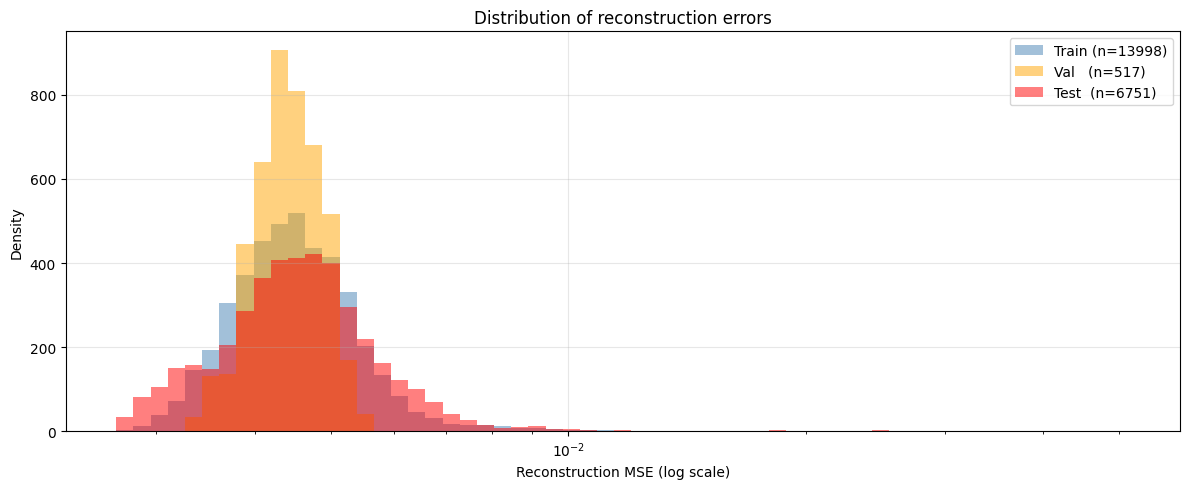


Quantiles (train):
   50.0%: 0.00459
   90.0%: 0.00583
   95.0%: 0.00645
   99.0%: 0.00879
   99.9%: 0.01213
  100.0%: 0.02056


In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

# Use log-scaled bins to see the full range
bins = np.logspace(np.log10(err_train.min()), np.log10(max(err_test.max(), err_train.max())), 60)

ax.hist(err_train, bins=bins, alpha=0.5, density=True, label=f'Train (n={len(err_train)})', color='steelblue')
ax.hist(err_val,   bins=bins, alpha=0.5, density=True, label=f'Val   (n={len(err_val)})',   color='orange')
ax.hist(err_test,  bins=bins, alpha=0.5, density=True, label=f'Test  (n={len(err_test)})',  color='red')

ax.set_xscale('log')
ax.set_xlabel('Reconstruction MSE (log scale)')
ax.set_ylabel('Density')
ax.set_title('Distribution of reconstruction errors')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Also print some useful quantiles
print(f"\nQuantiles (train):")
for q in [0.50, 0.90, 0.95, 0.99, 0.999, 1.0]:
    print(f"  {q*100:5.1f}%: {np.quantile(err_train, q):.5f}")

In [4]:
def label_windows_by_end_timestamp(
    timestamps: np.ndarray,
    anomaly_windows: list,
    window_size: int = pp.WINDOW_SIZE,
) -> np.ndarray:
    """Binary label for each window: True if its end timestamp falls
    inside any labelled anomaly window."""
    n_windows = len(timestamps) - window_size + 1
    end_timestamps = timestamps[window_size - 1 : window_size - 1 + n_windows]
    labels = np.zeros(n_windows, dtype=bool)
    for start, end in anomaly_windows:
        in_window = (end_timestamps >= np.datetime64(start)) & (end_timestamps <= np.datetime64(end))
        labels |= in_window
    return labels


# Ground truth labels for test windows
y_test = label_windows_by_end_timestamp(
    test_df['timestamp'].values, anomaly_windows
)

print(f"Test windows total:    {len(y_test):,}")
print(f"Anomalous windows:     {y_test.sum():,}  ({100 * y_test.mean():.1f}%)")
print(f"Normal windows:        {(~y_test).sum():,}  ({100 * (~y_test).mean():.1f}%)")

Test windows total:    6,751
Anomalous windows:     1,134  (16.8%)
Normal windows:        5,617  (83.2%)


In [5]:
# Threshold from the 99th percentile of training errors
threshold = np.quantile(err_train, 0.99)
print(f"Threshold (99th percentile of training): {threshold:.5f}\n")

# Apply threshold
y_pred = err_test > threshold

# Confusion matrix
tp = int((y_pred & y_test).sum())
fp = int((y_pred & ~y_test).sum())
fn = int((~y_pred & y_test).sum())
tn = int((~y_pred & ~y_test).sum())

print(f"{'':>20} {'Predicted +':>12} {'Predicted -':>12}")
print(f"{'Actual + (anomaly)':>20} {tp:>12,} {fn:>12,}")
print(f"{'Actual - (normal)':>20} {fp:>12,} {tn:>12,}")

# Metrics
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
fpr       = fp / (fp + tn) if (fp + tn) > 0 else 0.0

print(f"\nPrecision: {precision:.3f}  ({tp}/{tp+fp} flagged windows were actual anomalies)")
print(f"Recall:    {recall:.3f}  ({tp}/{tp+fn} actual anomalous windows were detected)")
print(f"F1:        {f1:.3f}")
print(f"FPR:       {fpr:.3f}  ({fp}/{fp+tn} normal windows were flagged)")

Threshold (99th percentile of training): 0.00879

                      Predicted +  Predicted -
  Actual + (anomaly)           18        1,116
   Actual - (normal)          154        5,463

Precision: 0.105  (18/172 flagged windows were actual anomalies)
Recall:    0.016  (18/1134 actual anomalous windows were detected)
F1:        0.028
FPR:       0.027  (154/5617 normal windows were flagged)


C:\Users\Hp\AppData\Local\Temp\ipykernel_23240\788554699.py:9: RuntimeWarning: invalid value encountered in divide
  2 * precisions * recalls / (precisions + recalls),


Best F1:        0.320
  at threshold: 0.00479
  precision:    0.216
  recall:       0.611
Average precision (area under PR curve): 0.220

For comparison:
  Random baseline F1 = 0.288
  Random baseline AP = 0.168


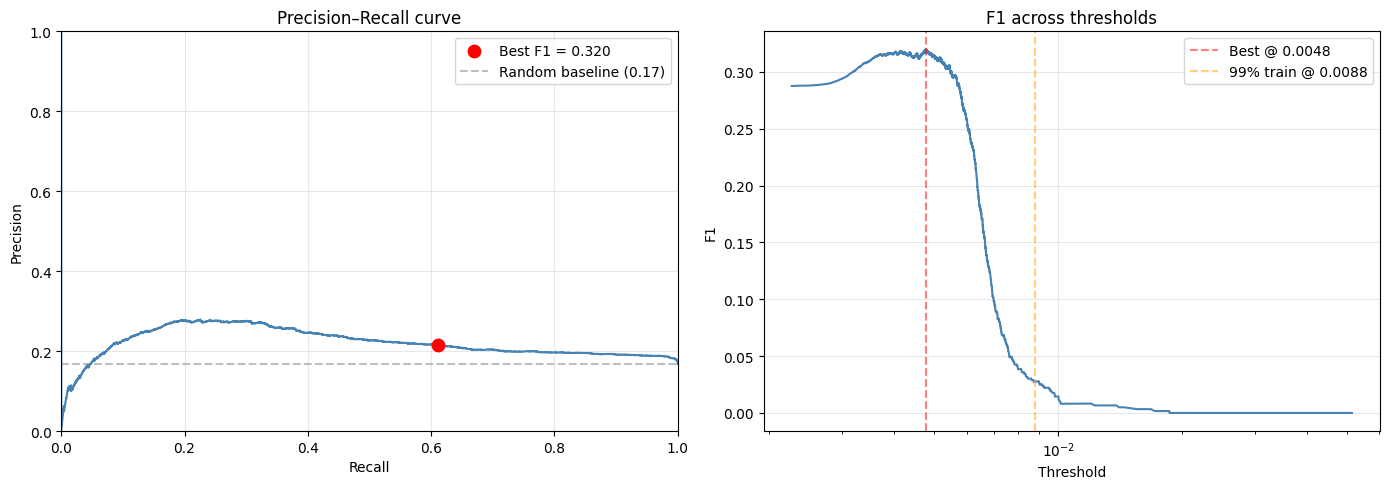

In [7]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Sweep all thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, err_test)

# F1 at each threshold (avoid divide-by-zero)
f1s = np.where(
    (precisions + recalls) > 0,
    2 * precisions * recalls / (precisions + recalls),
    0.0,
)

# Best F1 and its threshold
# Note: precision_recall_curve returns N+1 P/R points but only N thresholds.
# Drop the final P/R point (which is the all-positive trivial case) to align with thresholds.
best_idx = np.argmax(f1s[:-1])
best_threshold = thresholds[best_idx]
best_f1 = f1s[best_idx]
best_precision = precisions[best_idx]
best_recall = recalls[best_idx]
ap = average_precision_score(y_test, err_test)

print(f"Best F1:        {best_f1:.3f}")
print(f"  at threshold: {best_threshold:.5f}")
print(f"  precision:    {best_precision:.3f}")
print(f"  recall:       {best_recall:.3f}")
print(f"Average precision (area under PR curve): {ap:.3f}")
print()
print(f"For comparison:")
print(f"  Random baseline F1 = {2 * y_test.mean() / (1 + y_test.mean()):.3f}")
print(f"  Random baseline AP = {y_test.mean():.3f}")

# Plot PR curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recalls, precisions, color='steelblue')
axes[0].scatter([best_recall], [best_precision], color='red', s=80, zorder=5, label=f'Best F1 = {best_f1:.3f}')
axes[0].axhline(y_test.mean(), color='gray', linestyle='--', alpha=0.5, label=f'Random baseline ({y_test.mean():.2f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision–Recall curve')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# F1 vs threshold
axes[1].plot(thresholds, f1s[:-1], color='steelblue')
axes[1].axvline(best_threshold, color='red', linestyle='--', alpha=0.5, label=f'Best @ {best_threshold:.4f}')
axes[1].axvline(np.quantile(err_train, 0.99), color='orange', linestyle='--', alpha=0.5, label=f'99% train @ {np.quantile(err_train, 0.99):.4f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1')
axes[1].set_title('F1 across thresholds')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
def detect_events(
    err: np.ndarray,
    threshold: float,
    timestamps: np.ndarray,
    window_size: int = pp.WINDOW_SIZE,
    merge_gap_minutes: int = 30,
) -> list:
    """Group consecutive flagged windows into discrete detection events.

    Returns a list of (event_start_ts, event_end_ts) pairs. Detections
    within merge_gap_minutes of each other are merged into one event,
    so a single anomaly producing several adjacent above-threshold
    windows counts as one event, not many.
    """
    flagged = err > threshold
    end_indices = np.arange(window_size - 1, window_size - 1 + len(err))
    flagged_timestamps = pd.to_datetime(timestamps[end_indices][flagged])

    if len(flagged_timestamps) == 0:
        return []

    events = []
    event_start = flagged_timestamps[0]
    event_end = flagged_timestamps[0]
    merge_gap = pd.Timedelta(minutes=merge_gap_minutes)

    for t in flagged_timestamps[1:]:
        if t - event_end <= merge_gap:
            event_end = t
        else:
            events.append((event_start, event_end))
            event_start = t
            event_end = t
    events.append((event_start, event_end))
    return events


def score_events(detected_events: list, true_windows: list) -> dict:
    """Compare detected events to labelled anomaly windows.

    A detected event is a true positive if it overlaps (in time) with
    any labelled window. A labelled window is detected if any event
    overlaps with it. Other detected events are false alarms.
    """
    detected_overlaps = [False] * len(detected_events)
    true_detected = [False] * len(true_windows)

    for i, (d_start, d_end) in enumerate(detected_events):
        for j, (t_start, t_end) in enumerate(true_windows):
            # Overlap test: not (d ends before t starts) and not (d starts after t ends)
            if d_end >= t_start and d_start <= t_end:
                detected_overlaps[i] = True
                true_detected[j] = True

    tp = sum(true_detected)
    fp = sum(1 for x in detected_overlaps if not x)
    fn = sum(1 for x in true_detected if not x)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "tp_events": tp, "fp_events": fp, "fn_events": fn,
        "precision": precision, "recall": recall, "f1": f1,
        "detected_events": detected_events,
        "missed_events": [w for w, d in zip(true_windows, true_detected) if not d],
    }


# Only count anomaly windows that actually fall in the test period
test_anomaly_windows = [
    (s, e) for s, e in anomaly_windows
    if s >= pp.DEFAULT_SPLIT.test_start and s < pp.DEFAULT_SPLIT.test_end
]

# Try a few thresholds
for label, threshold in [
    ("99th percentile train", np.quantile(err_train, 0.99)),
    ("99.9th percentile train", np.quantile(err_train, 0.999)),
    ("Max of training", err_train.max()),
    ("Best per-window F1", 0.00479),
]:
    events = detect_events(err_test, threshold, test_df['timestamp'].values)
    scores = score_events(events, test_anomaly_windows)

    print(f"\n--- Threshold: {label} ({threshold:.5f}) ---")
    print(f"  Detected events:  {scores['tp_events'] + scores['fp_events']}")
    print(f"  True positives:   {scores['tp_events']}/{len(test_anomaly_windows)}")
    print(f"  False alarms:     {scores['fp_events']}")
    print(f"  Missed events:    {scores['fn_events']}")
    print(f"  Event-level F1:   {scores['f1']:.3f}")


--- Threshold: 99th percentile train (0.00879) ---
  Detected events:  8
  True positives:   2/2
  False alarms:     6
  Missed events:    0
  Event-level F1:   0.400

--- Threshold: 99.9th percentile train (0.01213) ---
  Detected events:  7
  True positives:   1/2
  False alarms:     6
  Missed events:    1
  Event-level F1:   0.222

--- Threshold: Max of training (0.02056) ---
  Detected events:  2
  True positives:   0/2
  False alarms:     2
  Missed events:    2
  Event-level F1:   0.000

--- Threshold: Best per-window F1 (0.00479) ---
  Detected events:  64
  True positives:   2/2
  False alarms:     62
  Missed events:    0
  Event-level F1:   0.061


In [12]:
# Compute confidence scores for all three splits
conf_train = md.confidence_score(err_train)
conf_val   = md.confidence_score(err_val)
conf_test  = md.confidence_score(err_test)

print(f"Train confidence: min={conf_train.min():.2f}, mean={conf_train.mean():.2f}, max={conf_train.max():.2f}")
print(f"Val confidence:   min={conf_val.min():.2f},   mean={conf_val.mean():.2f},   max={conf_val.max():.2f}")
print(f"Test confidence:  min={conf_test.min():.2f},   mean={conf_test.mean():.2f},   max={conf_test.max():.2f}")
print()
print(f"Fraction of windows above 0 (would flag):")
print(f"  Train: {(conf_train > 0).mean():.4f}")
print(f"  Val:   {(conf_val > 0).mean():.4f}")
print(f"  Test:  {(conf_test > 0).mean():.4f}")

Train confidence: min=-0.70, mean=-0.46, max=1.34
Val confidence:   min=-0.62,   mean=-0.49,   max=-0.36
Test confidence:  min=-0.74,   mean=-0.42,   max=4.86

Fraction of windows above 0 (would flag):
  Train: 0.0101
  Val:   0.0000
  Test:  0.0255


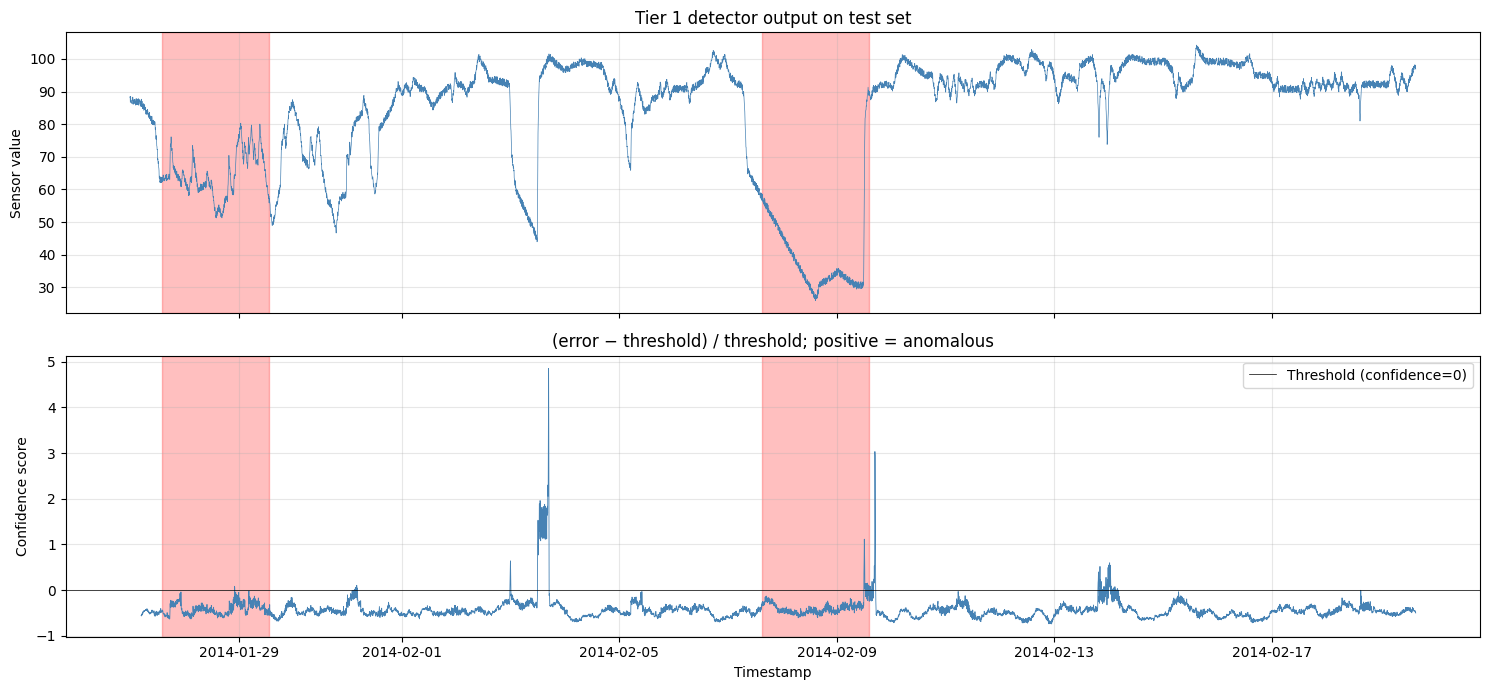

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

# Top: signal with labelled anomalies
axes[0].plot(test_df['timestamp'], test_df['value'], linewidth=0.5, color='steelblue')
for start, end in test_anomaly_windows:
    axes[0].axvspan(start, end, color='red', alpha=0.25)
axes[0].set_ylabel('Sensor value')
axes[0].set_title('Tier 1 detector output on test set')
axes[0].grid(True, alpha=0.3)

# Bottom: confidence score over time
test_timestamps = test_df['timestamp'].values
end_indices = np.arange(pp.WINDOW_SIZE - 1, pp.WINDOW_SIZE - 1 + len(conf_test))
confidence_timestamps = test_timestamps[end_indices]

axes[1].plot(confidence_timestamps, conf_test, linewidth=0.6, color='steelblue')
axes[1].axhline(0, color='black', linewidth=0.5, label='Threshold (confidence=0)')
for start, end in test_anomaly_windows:
    axes[1].axvspan(start, end, color='red', alpha=0.25)
axes[1].set_xlabel('Timestamp')
axes[1].set_ylabel('Confidence score')
axes[1].set_title('(error − threshold) / threshold; positive = anomalous')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()